# Calcolo della f0 su tutto il dataset

In [84]:
import os
import numpy as np
import matplotlib.pyplot as plt
import scipy as sp
from lib.readwav import readwav
import ipywidgets as widgets
import json

In [85]:
%matplotlib widget
plt.close('all')

Abbiamo alcune opzioni da confrontare per il calcolo della f0, tra cui:
- primo picco dello spettro di potenza
- gcd approx
- regressione lineare
- bayesiano

In [86]:
def get_f0_first_peak(peak_freqs, freqs, spectrum):
    return peak_freqs[0] if len(peak_freqs) > 0 else None


def get_f0_from_gcd(peak_freqs):
    if len(peak_freqs) < 2:
        return None  # Non abbastanza picchi per calcolare la f0

    fmin = np.min(peak_freqs) / 2
    fmax = np.min(peak_freqs)
    candidates = np.arange(fmin, fmax, 0.05)

    best_f0 = None
    best_score = float('inf')

    for f0 in candidates:
        residual = np.sum(np.abs((peak_freqs / f0) - np.round(peak_freqs / f0)))

        if residual < best_score and np.round(peak_freqs / f0).min() > 0:  # Assicurati che ci siano armoniche valide
            best_score = residual
            best_f0 = f0
    
    return best_f0

def get_f0_linear_regression(peak_freqs):
    if len(peak_freqs) < 2:
        return None  # Non abbastanza picchi per la regressione lineare
    x = np.arange(1, len(peak_freqs) + 1)
    y = peak_freqs
    A = np.vstack([x, np.ones(len(x))]).T
    m, c = np.linalg.lstsq(A, y, rcond=None)[0]
    return m  # La pendenza della retta è la f0 stimata

def get_f0_bayesian(peak_freqs):
    pass  # lunghetto da implementare e work in progress


In [87]:
base_dir = "dati_processati"
peak_file = "spettri_5_periodi_peaks.json"

filepath = os.path.join(base_dir, peak_file)

with open(filepath, 'r') as f:
    peaks_dict = json.load(f)


In [88]:
# calcola f0 per ogni campione usando i diversi metodi
f0_results = {}
for sample, data in peaks_dict.items():
    print(f"Processing {sample}...")
    freqs = np.array(data["peaks"]['frequencies'])
    mags = np.array(data["peaks"]['magnitudes'])

    f0_results[sample] = {
        'first_peak': get_f0_first_peak(freqs, freqs, mags),
        'gcd': get_f0_from_gcd(freqs),
        'linear_regression': get_f0_linear_regression(freqs),
        'bayesian': get_f0_bayesian(freqs)
    }

Processing Nota_1...
Processing Nota_2...
Processing Nota_3...
Processing Nota_4...
Processing Nota_5...
Processing Nota_6...
Processing Nota_7...
Processing Nota_8...
Processing Nota_9...
Processing Nota_10...
Processing Nota_11...
Processing Nota_12...
Processing Nota_13...
Processing Nota_14...
Processing Nota_15...
Processing Nota_16...
Processing Nota_17...
Processing Nota_18...
Processing Nota_19...
Processing Nota_20...
Processing Nota_21...
Processing Nota_22...
Processing Nota_23...
Processing Nota_24...
Processing Nota_25...
Processing Nota_26...
Processing Nota_27...
Processing Nota_28...
Processing Nota_29...
Processing Nota_30...
Processing Nota_31...
Processing Nota_32...
Processing Nota_33...
Processing Nota_34...
Processing Nota_35...
Processing Nota_36...
Processing Nota_37...
Processing Nota_38...
Processing Nota_39...
Processing Nota_40...
Processing Nota_41...
Processing Nota_42...
Processing Nota_43...
Processing Nota_44...
Processing Nota_45...
Processing Nota_46.

In [89]:
for sample, results in f0_results.items():
    print(f"{sample}:")
    for method, f0 in results.items():
        print(f"  {method}: {f0}")

Nota_1:
  first_peak: 1578.947368421053
  gcd: 1563.1736842098228
  linear_regression: 1912.8450496871553
  bayesian: None
Nota_2:
  first_peak: 1500.0
  gcd: 1481.9999999993342
  linear_regression: 1582.0000000000002
  bayesian: None
Nota_3:
  first_peak: 331.03448275862075
  gcd: 330.81724137934793
  linear_regression: 456.18349196442523
  bayesian: None
Nota_4:
  first_peak: 169.91150442477877
  gcd: 87.05575221238927
  linear_regression: 192.63124755850117
  bayesian: None
Nota_5:
  first_peak: 215.7303370786517
  gcd: 110.4151685393257
  linear_regression: 277.1187630324906
  bayesian: None
Nota_6:
  first_peak: 467.8362573099415
  gcd: 467.81812865502394
  linear_regression: 467.2124756335283
  bayesian: None
Nota_7:
  first_peak: 176.47058823529414
  gcd: 175.5852941176421
  linear_regression: 788.0422322775266
  bayesian: None
Nota_8:
  first_peak: 757.8947368421054
  gcd: 391.5973684210556
  linear_regression: 913.9865047233471
  bayesian: None
Nota_9:
  first_peak: 156.734693

In [90]:
# cstruisci un dizionario con le frequenze delle note dalla prima ottava fino alla quinta, sfruttando l'andamento esponenziale delle frequenze
note_freqs = {}
for octave in range(1, 7):
    for i, note in enumerate(["DO", "DO#", "RE", "RE#", "MI", "FA", "FA#", "SOL", "SOL#", "LA", "LA#", "SI"]):
        freq = 16.35 * (2 ** octave) * (2 ** (i / 12))
        note_freqs[f"{note}{octave}"] = freq

print("Frequenze delle note:")
for note, freq in note_freqs.items():
    print(f"  {note}: {freq:.2f} Hz")

Frequenze delle note:
  DO1: 32.70 Hz
  DO#1: 34.64 Hz
  RE1: 36.70 Hz
  RE#1: 38.89 Hz
  MI1: 41.20 Hz
  FA1: 43.65 Hz
  FA#1: 46.24 Hz
  SOL1: 48.99 Hz
  SOL#1: 51.91 Hz
  LA1: 54.99 Hz
  LA#1: 58.26 Hz
  SI1: 61.73 Hz
  DO2: 65.40 Hz
  DO#2: 69.29 Hz
  RE2: 73.41 Hz
  RE#2: 77.77 Hz
  MI2: 82.40 Hz
  FA2: 87.30 Hz
  FA#2: 92.49 Hz
  SOL2: 97.99 Hz
  SOL#2: 103.82 Hz
  LA2: 109.99 Hz
  LA#2: 116.53 Hz
  SI2: 123.46 Hz
  DO3: 130.80 Hz
  DO#3: 138.58 Hz
  RE3: 146.82 Hz
  RE#3: 155.55 Hz
  MI3: 164.80 Hz
  FA3: 174.60 Hz
  FA#3: 184.98 Hz
  SOL3: 195.98 Hz
  SOL#3: 207.63 Hz
  LA3: 219.98 Hz
  LA#3: 233.06 Hz
  SI3: 246.92 Hz
  DO4: 261.60 Hz
  DO#4: 277.16 Hz
  RE4: 293.64 Hz
  RE#4: 311.10 Hz
  MI4: 329.60 Hz
  FA4: 349.19 Hz
  FA#4: 369.96 Hz
  SOL4: 391.96 Hz
  SOL#4: 415.26 Hz
  LA4: 439.96 Hz
  LA#4: 466.12 Hz
  SI4: 493.84 Hz
  DO5: 523.20 Hz
  DO#5: 554.31 Hz
  RE5: 587.27 Hz
  RE#5: 622.19 Hz
  MI5: 659.19 Hz
  FA5: 698.39 Hz
  FA#5: 739.92 Hz
  SOL5: 783.91 Hz
  SOL#5: 830.5

In [91]:
types = [
    "first_peak",
    "gcd",
    "linear_regression",
    "bayesian"
]

# separa i risultati per metodo e rimiovi i None
method_results = {method: [] for method in types}
for sample, results in f0_results.items():
    for method in types:
        method_results[method].append(results[method])

# rimuovi i None values
for method in types:
    method_results[method] = [freq for freq in method_results[method] if freq is not None]


# binning dei risultati nelle note più vicine
def find_closest_note(freq, note_freqs):
    closest_note = None
    min_diff = float('inf')
    for note, note_freq in note_freqs.items():
        diff = abs(freq - note_freq)
        if diff < min_diff:
            min_diff = diff
            closest_note = note
    return closest_note

binned_results = {method: [] for method in types}
for method in types:
    for freq in method_results[method]:
        if freq is not None:
            closest_note = find_closest_note(freq, note_freqs)
            binned_results[method].append(closest_note)
        else:
            binned_results[method].append(None)



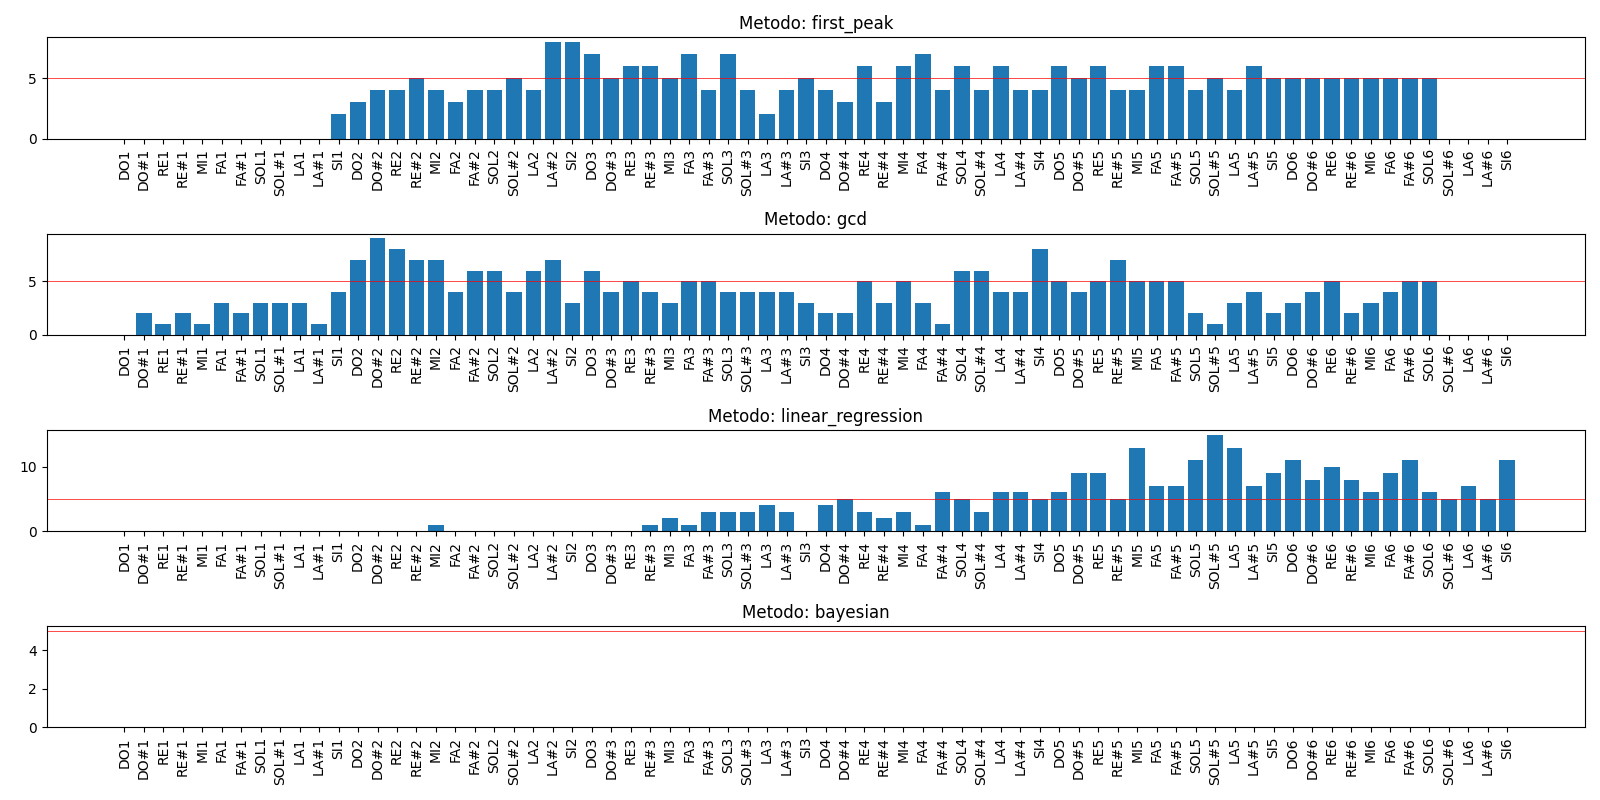

In [92]:
ordered_notes = list(note_freqs.keys())
fig, axs = plt.subplots(len(types), 1, figsize=(16, 8))

for i, method in enumerate(types):
    counts = [binned_results[method].count(note) for note in ordered_notes]
    axs[i].bar(np.arange(len(ordered_notes)), counts, width=0.8)
    axs[i].set_title(f"Metodo: {method}")
    axs[i].set_xticks(np.arange(len(ordered_notes)))
    axs[i].set_xticklabels(ordered_notes, rotation=90)
    axs[i].axhline(5, color='red', linewidth=0.5)

plt.tight_layout()
plt.show()


In [93]:
res_gcd = method_results['gcd']

for freq in res_gcd:
    closest_note = find_closest_note(freq, note_freqs)
    print(f"Frequenza: {freq:.2f} Hz, Nota più vicina: {closest_note}")

Frequenza: 1563.17 Hz, Nota più vicina: SOL6
Frequenza: 1482.00 Hz, Nota più vicina: FA#6
Frequenza: 330.82 Hz, Nota più vicina: MI4
Frequenza: 87.06 Hz, Nota più vicina: FA2
Frequenza: 110.42 Hz, Nota più vicina: LA2
Frequenza: 467.82 Hz, Nota più vicina: LA#4
Frequenza: 175.59 Hz, Nota più vicina: FA3
Frequenza: 391.60 Hz, Nota più vicina: SOL4
Frequenza: 156.47 Hz, Nota più vicina: RE#3
Frequenza: 116.67 Hz, Nota più vicina: LA#2
Frequenza: 1399.63 Hz, Nota più vicina: FA6
Frequenza: 1178.88 Hz, Nota più vicina: RE6
Frequenza: 524.28 Hz, Nota più vicina: DO5
Frequenza: 277.67 Hz, Nota più vicina: DO#4
Frequenza: 1052.03 Hz, Nota più vicina: DO6
Frequenza: 743.38 Hz, Nota più vicina: FA#5
Frequenza: 94.63 Hz, Nota più vicina: FA#2
Frequenza: 92.45 Hz, Nota più vicina: FA#2
Frequenza: 144.52 Hz, Nota più vicina: RE3
Frequenza: 415.63 Hz, Nota più vicina: SOL#4
Frequenza: 172.44 Hz, Nota più vicina: FA3
Frequenza: 117.29 Hz, Nota più vicina: LA#2
Frequenza: 70.85 Hz, Nota più vicina: D